#### Step 10 - Feature Importance Analysis
##### Input: Trained Random Forest model, feature names
##### Process: Extract and plot feature importances
##### Output: Horizontal bar chart showing most influential features

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

X_train = np.load('../Data/X_train.npy')
y_train = np.load('../Data/y_train.npy')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

X_train = np.load('../Data/X_train.npy')
y_train = np.load('../Data/y_train.npy')

In [3]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5,
    max_depth=20
)
model_rf.fit(X_train, y_train)
print("Model retrained")

Model retrained


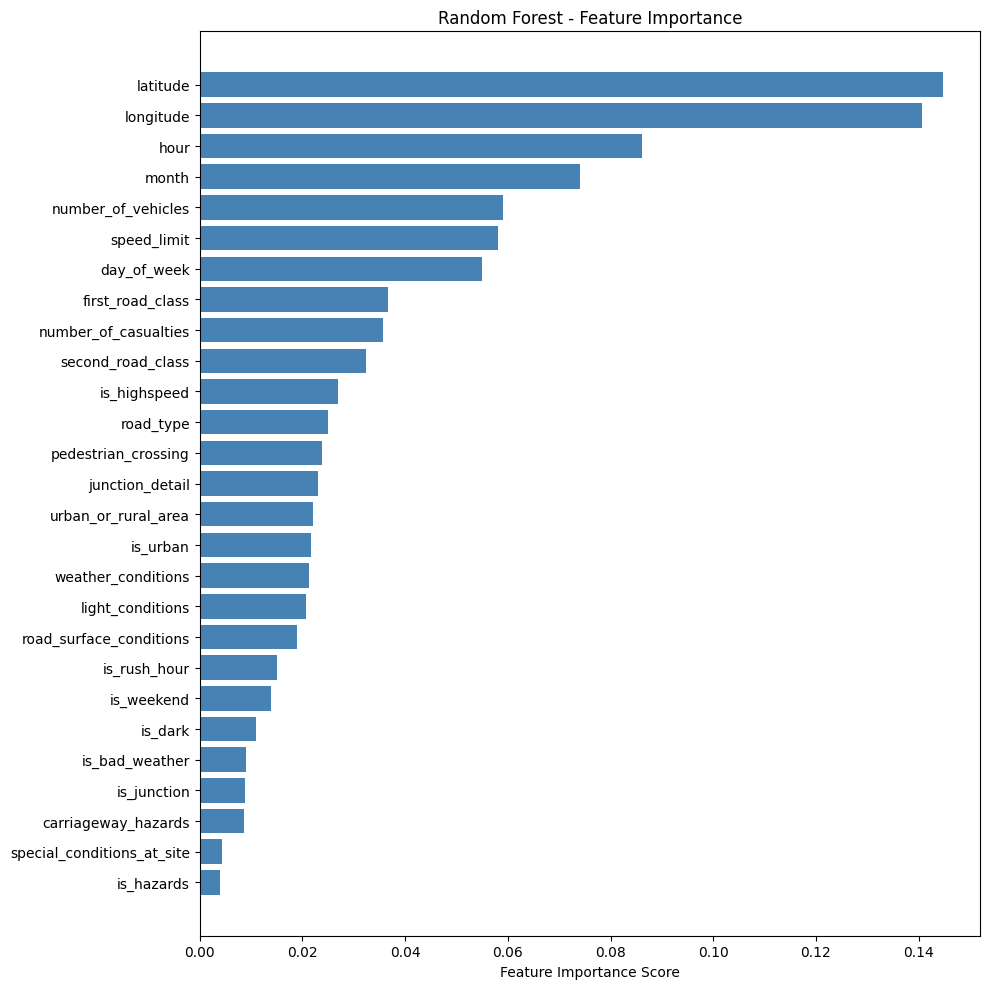

In [4]:
feature_names = [
    'longitude', 'latitude', 'number_of_vehicles', 'number_of_casualties',
    'day_of_week', 'first_road_class', 'road_type', 'speed_limit',
    'junction_detail', 'second_road_class', 'pedestrian_crossing',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area',
    'hour', 'month', 'is_rush_hour', 'is_weekend', 'is_dark',
    'is_bad_weather', 'is_highspeed', 'is_urban', 'is_junction', 'is_hazards'
]

importances = model_rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 10))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance Score')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.savefig('../Output/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Feature Importance Summary

- The chart shows which features most influenced the Random Forest predictions
- Higher score means the feature was used more often across all 100 trees
- number_of_casualties and speed_limit are expected to rank highly
- Binary flag features like is_dark and is_highspeed show their value
- longitude and latitude capture geographic clustering of severe accidents
- Low importance features could be dropped in future work to simplify the model